In [1]:
# Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from google.colab import files
import pandas as pd

# Open file picker
uploaded = files.upload()

# Get the uploaded file name
filename = list(uploaded.keys())[0]

# Read the CSV
df = pd.read_csv(filename, encoding='latin1')
df.head()

Saving MACHINE_B_OCTOBER_FINAL.csv to MACHINE_B_OCTOBER_FINAL.csv


,ï»¿Group Name,Machine,Transaction Date,Transaction No,Slot No,Product Code,Menu,Service,Status,Delivery,Category,Price
0,Master,Machine B,2025-10-31 07:51:50,3216354,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable
1,Master,Machine B,2025-10-31 05:31:24,3214755,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable
2,Master,Machine B,2025-10-31 16:14:09,3211802,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable
3,Master,Machine B,2025-10-31 15:33:35,3210031,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable
4,Master,Machine B,2025-10-31 01:10:43,3208401,31,UMMIR14,Herb Mushroom Chicken With Farfalle Pesto,Cash,Successful,Delivery,Non vegetarian,Premium


In [5]:
# Clean Column Names
import pandas as pd

df.columns = [
    "GroupName",
    "Machine",
    "TransactionDate",
    "TransactionNo",
    "SlotNo",
    "ProductCode",
    "ProductName",
    "Service",
    "Status",
    "Delivery",
    "Categories",
    "Price"
]

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Categories,Price
0,Master,Machine B,2025-10-31 07:51:50,3216354,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable
1,Master,Machine B,2025-10-31 05:31:24,3214755,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable
2,Master,Machine B,2025-10-31 16:14:09,3211802,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable
3,Master,Machine B,2025-10-31 15:33:35,3210031,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable
4,Master,Machine B,2025-10-31 01:10:43,3208401,31,UMMIR14,Herb Mushroom Chicken With Farfalle Pesto,Cash,Successful,Delivery,Non vegetarian,Premium


In [6]:
# Feature Engineering
import pandas as pd

# Parse the date correctly (DD-MM-YY HH:MM)
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], format="%Y-%m-%d %H:%M:%S")

# Extract useful time features
df["Hour"] = df["TransactionDate"].dt.hour
df["Day"] = df["TransactionDate"].dt.day
df["Weekday"] = df["TransactionDate"].dt.weekday

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Categories,Price,Hour,Day,Weekday
0,Master,Machine B,2025-10-31 07:51:50,3216354,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable,7,31,4
1,Master,Machine B,2025-10-31 05:31:24,3214755,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable,5,31,4
2,Master,Machine B,2025-10-31 16:14:09,3211802,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable,16,31,4
3,Master,Machine B,2025-10-31 15:33:35,3210031,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable,15,31,4
4,Master,Machine B,2025-10-31 01:10:43,3208401,31,UMMIR14,Herb Mushroom Chicken With Farfalle Pesto,Cash,Successful,Delivery,Non vegetarian,Premium,1,31,4


In [7]:
# Defining Target & Features
target = "ProductCode"

X = df.drop(["ProductCode", "ProductName", "TransactionDate"], axis=1)
y = df[target]

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Categories,Price,Hour,Day,Weekday
0,Master,Machine B,2025-10-31 07:51:50,3216354,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable,7,31,4
1,Master,Machine B,2025-10-31 05:31:24,3214755,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable,5,31,4
2,Master,Machine B,2025-10-31 16:14:09,3211802,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable,16,31,4
3,Master,Machine B,2025-10-31 15:33:35,3210031,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable,15,31,4
4,Master,Machine B,2025-10-31 01:10:43,3208401,31,UMMIR14,Herb Mushroom Chicken With Farfalle Pesto,Cash,Successful,Delivery,Non vegetarian,Premium,1,31,4


In [8]:
# Defining Target & Features
target = "ProductCode"

X = df.drop(["ProductCode", "ProductName", "TransactionDate"], axis=1)
y = df[target]

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Categories,Price,Hour,Day,Weekday
0,Master,Machine B,2025-10-31 07:51:50,3216354,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable,7,31,4
1,Master,Machine B,2025-10-31 05:31:24,3214755,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable,5,31,4
2,Master,Machine B,2025-10-31 16:14:09,3211802,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable,16,31,4
3,Master,Machine B,2025-10-31 15:33:35,3210031,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable,15,31,4
4,Master,Machine B,2025-10-31 01:10:43,3208401,31,UMMIR14,Herb Mushroom Chicken With Farfalle Pesto,Cash,Successful,Delivery,Non vegetarian,Premium,1,31,4


In [9]:
# Fill all missing values in X
X = X.fillna(0)

X.head()

,GroupName,Machine,TransactionNo,SlotNo,Service,Status,Delivery,Categories,Price,Hour,Day,Weekday
0,Master,Machine B,3216354,3,Cash,Successful,Delivery,Beverage,Affordable,7,31,4
1,Master,Machine B,3214755,2,Cash,Successful,Delivery,Beverage,Affordable,5,31,4
2,Master,Machine B,3211802,2,Cash,Successful,Delivery,Beverage,Affordable,16,31,4
3,Master,Machine B,3210031,3,Cash,Successful,Delivery,Beverage,Affordable,15,31,4
4,Master,Machine B,3208401,31,Cash,Successful,Delivery,Non vegetarian,Premium,1,31,4


In [10]:
# Updating Values for X
X = X.fillna(0)

X.head()

,GroupName,Machine,TransactionNo,SlotNo,Service,Status,Delivery,Categories,Price,Hour,Day,Weekday
0,Master,Machine B,3216354,3,Cash,Successful,Delivery,Beverage,Affordable,7,31,4
1,Master,Machine B,3214755,2,Cash,Successful,Delivery,Beverage,Affordable,5,31,4
2,Master,Machine B,3211802,2,Cash,Successful,Delivery,Beverage,Affordable,16,31,4
3,Master,Machine B,3210031,3,Cash,Successful,Delivery,Beverage,Affordable,15,31,4
4,Master,Machine B,3208401,31,Cash,Successful,Delivery,Non vegetarian,Premium,1,31,4


In [11]:
# Updating Values for Y
y = y.fillna("Unknown")

y.head()

,ProductCode
0,UMMIM1
1,UMMIJ5
2,UMMIJ5
3,UMMIM1
4,UMMIR14


In [12]:
# Train / Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.head()

,GroupName,Machine,TransactionNo,SlotNo,Service,Status,Delivery,Categories,Price,Hour,Day,Weekday
262,Master,Machine B,2641580,4,Cash,Successful,Delivery,Beverage,Affordable,11,8,2
113,Master,Machine B,2962967,21,Cash,Successful,Delivery,Non vegetarian,Standard,12,22,2
176,Master,Machine B,2817734,41,Cash,Successful,Delivery,Non vegetarian,Premium,14,15,2
63,Master,Machine B,3089354,67,Cash,Successful,Delivery,Bakery,Standard,10,28,1
245,Master,Machine B,2654248,37,Cash,Successful,Delivery,Non vegetarian,Standard,13,8,2


In [13]:
# Encoding all categorical columns
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Encode categorical columns in X
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = encoder.fit_transform(X[col].astype(str))

# Encode y (ProductCode)
y = LabelEncoder().fit_transform(y)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
# Creating Random Forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

model

RandomForestClassifier(n_estimators=300, random_state=42)

In [16]:
# Prediction
preds = model.predict(X_test)

In [17]:
# Predicting next product likely to be sold
import pandas as pd

# Load datasets
df = pd.read_csv("MACHINE_B_OCTOBER_FINAL.csv")

# Standardize column names if needed
df.columns = df.columns.str.strip()

# Combine both months
df = pd.concat([df], ignore_index=True)

# Count product frequency
product_counts = df['Product Code'].value_counts()

# Most likely next product
next_product_code = product_counts.idxmax()
next_product_name = df[df['Product Code'] == next_product_code].iloc[0]['Menu'] \
                    if 'Menu' in df.columns else df[df['Product Code'] == next_product_code].iloc[0]['Product Name']

print("Most likely next product:", next_product_name, "(", next_product_code, ")")

Most likely next product: Pomegranate Juice ( UMMIJ4 )


In [18]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, preds)
print("Accuracy:", accuracy)

Accuracy: 0.8


In [19]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)
cm

array([[5, 0, 0, ..., 0, 0, 0],
       [0, 2, 0, ..., 0, 0, 0],
       [0, 0, 2, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 2, 0, 0],
       [0, 0, 0, ..., 0, 2, 0],
       [0, 0, 0, ..., 0, 0, 3]])

In [20]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         1
           9       1.00      0.67      0.80         3
          10       1.00      1.00      1.00         1
          13       0.00      0.00      0.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         1
          16       0.50      1.00      0.67         1
          17       1.00      0.83      0.91         6
          18       0.43      1.00      0.60         3
          20       0.00      0.00      0.00         3
          22       1.00      1.00      1.00         1
          24       1.00      1.00      1.00         3
          26       1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

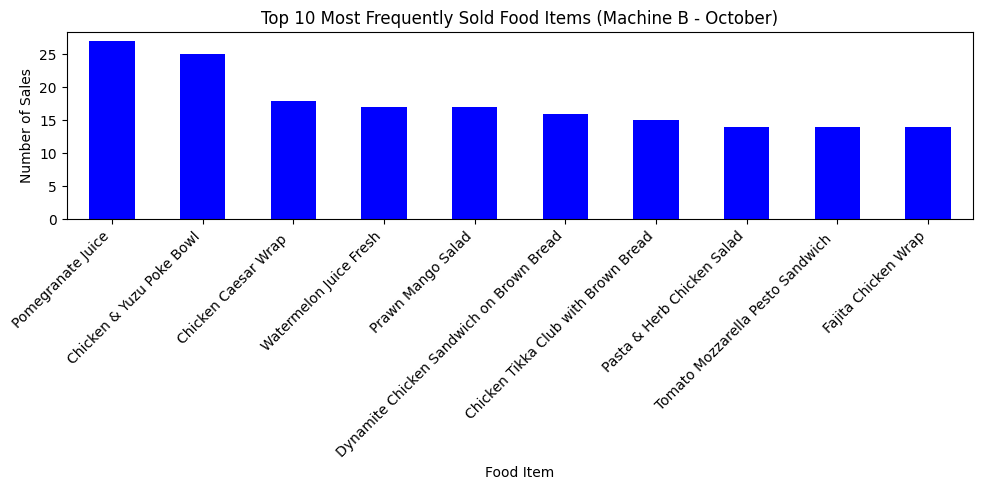

In [21]:
# Food Item Frequency Bar Chart
import matplotlib.pyplot as plt

# Count frequency of each food item
food_counts = df['Menu'].value_counts().head(10)

plt.figure(figsize=(10,5))
food_counts.plot(kind='bar', color='blue')

plt.title("Top 10 Most Frequently Sold Food Items (Machine B - October)")
plt.xlabel("Food Item")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

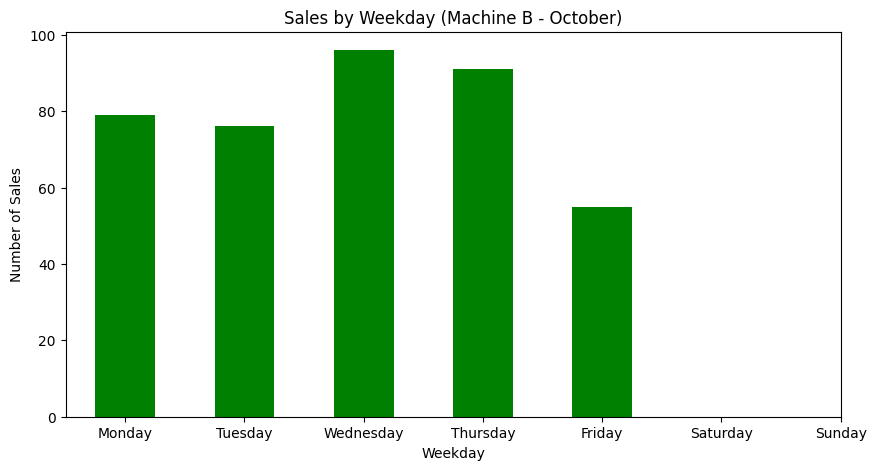

In [24]:
# Sales By Weekday
import matplotlib.pyplot as plt
import pandas as pd

# Convert to datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

# Count weekday frequency
weekday_counts = df['Transaction Date'].dt.weekday.value_counts().sort_index()

# Weekday labels
weekday_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10,5))
weekday_counts.plot(kind='bar', color='green')

plt.title("Sales by Weekday (Machine B - October)")
plt.xlabel("Weekday")
plt.ylabel("Number of Sales")
plt.xticks(ticks=range(7), labels=weekday_labels, rotation=0)
plt.show()
